In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [5]:
class State(TypedDict):
    review: str
    sentiment: str
    diagnosis_result: str
    feedback: str

In [ ]:
class SentimentSchema(BaseModel): # use for structured_output Model
    sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the review")

In [15]:
def find_sentiment(state: State):
    if True: return {"sentiment":'positive'}
    else: return {"sentiment":'negative'}
    
def run_diagnosis(state: State):
    return {"diagnosis_result":"XYZ"}

def generate_positive_feedback(state: State):
    return {"feedback": "You are Good"}

def generate_negative_res(state: State):
    return {"feedback": F"Diagnosis is {state['diagnosis_result']} need these improvements"}

def check_condition(state: State) -> Literal["run_diagnosis", "generate_positive_feedback"]:
    if state['sentiment'] == "negative": return "run_diagnosis"
    else: return "generate_positive_feedback"

In [16]:
graph = StateGraph(State)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("generate_negative_res", generate_negative_res)
graph.add_node("generate_positive_feedback", generate_positive_feedback)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_condition)
graph.add_edge("run_diagnosis", "generate_negative_res")
graph.add_edge("generate_negative_res", END)
graph.add_edge("generate_positive_feedback", END)

workflow = graph.compile()

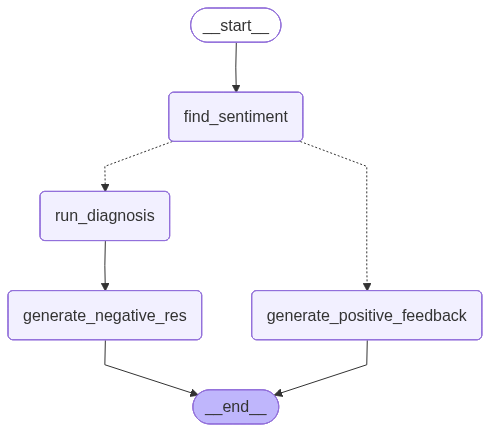

In [17]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())